<a href="https://colab.research.google.com/github/AswathyMohan-personal/alcatel-card-app/blob/master/learning1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

df = pd.read_csv("/content/dataset.csv")

#df.head()
df = df.drop('id',axis=1)
#df = df.drop('Unnamed')
#df.head()
numeric_cols = df.select_dtypes(include='number').columns
categoric_cols = df.select_dtypes(include = 'object').columns
print(f'numberic columns: {len(numeric_cols)}')
print(f'categoric columns: {len(categoric_cols)}')

numberic columns: 31
categoric columns: 1


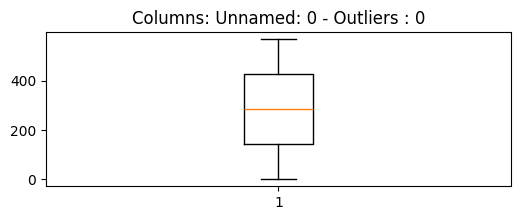

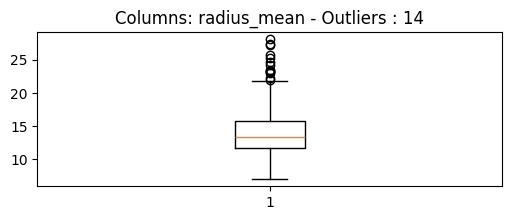

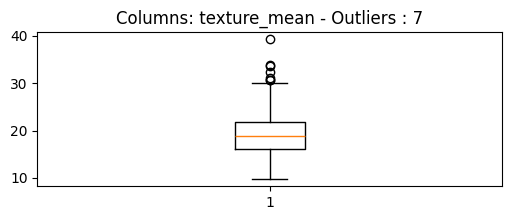

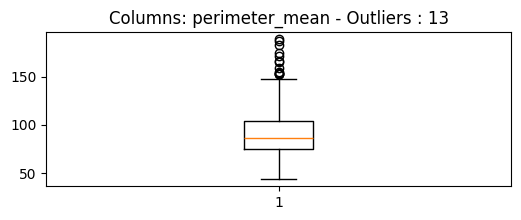

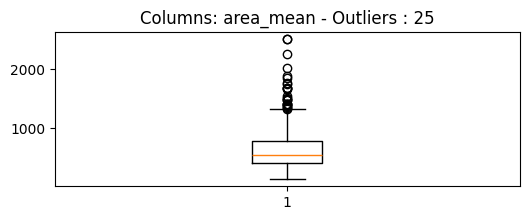

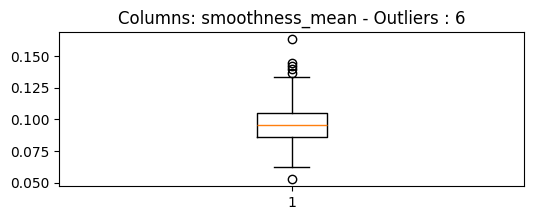

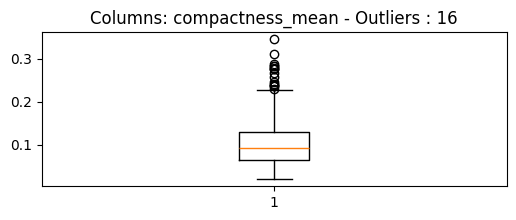

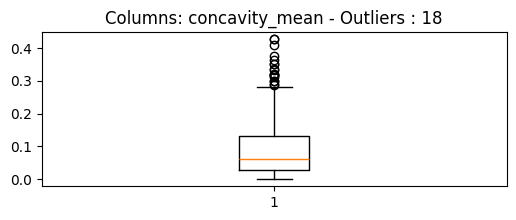

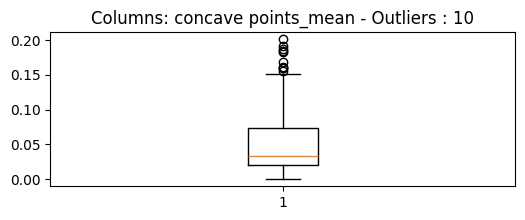

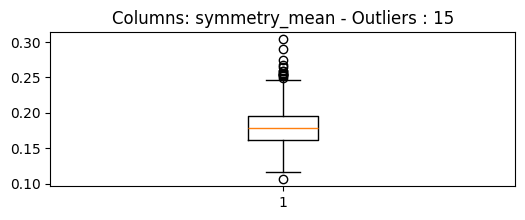

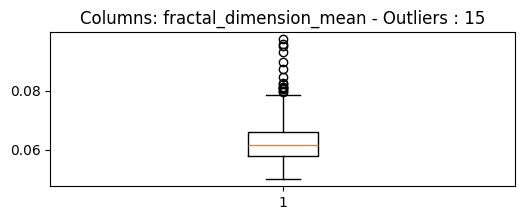

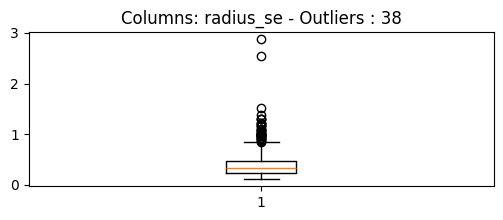

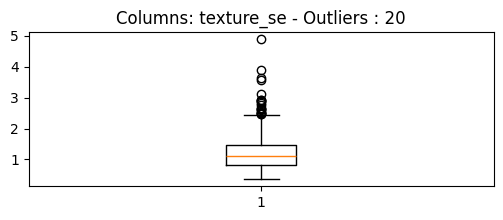

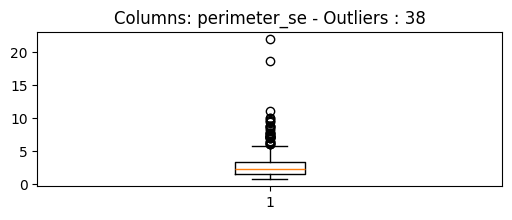

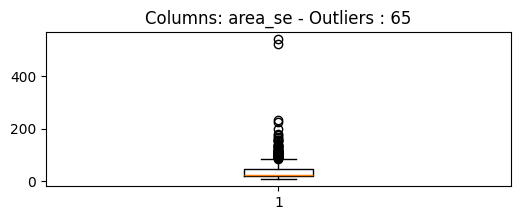

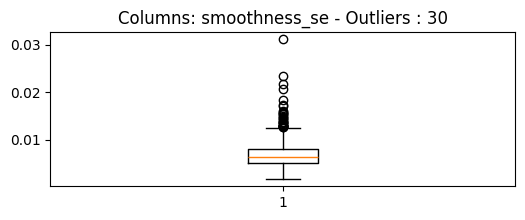

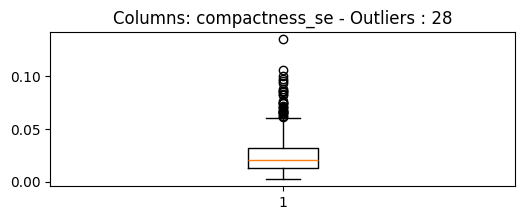

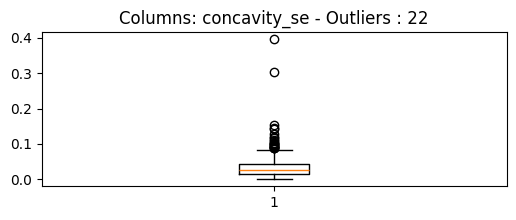

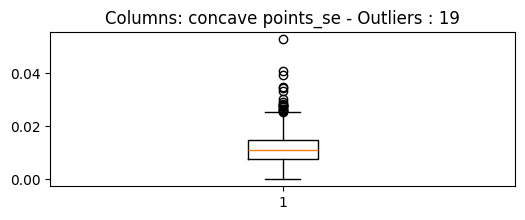

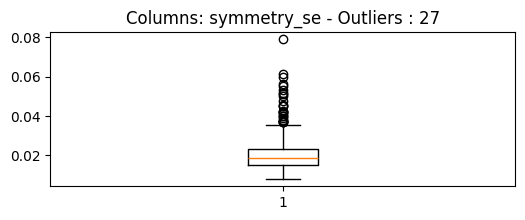

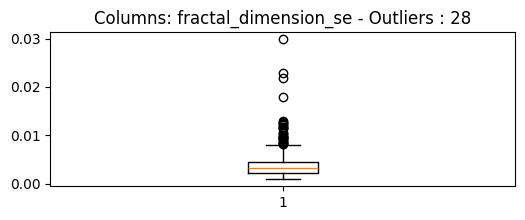

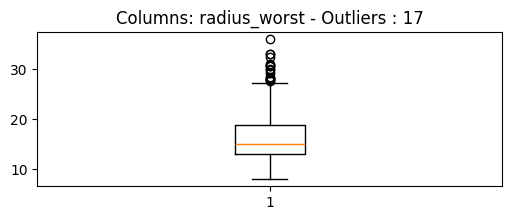

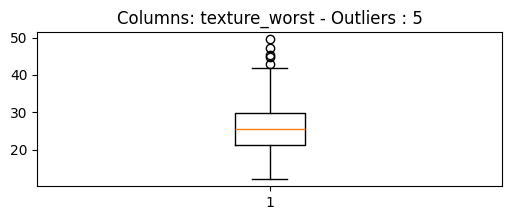

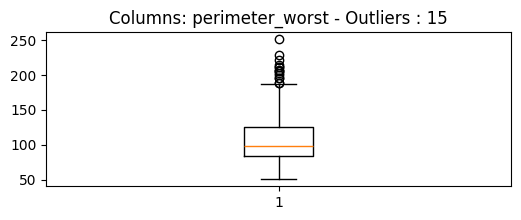

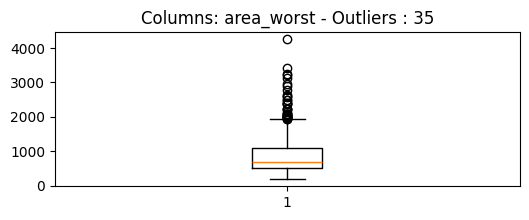

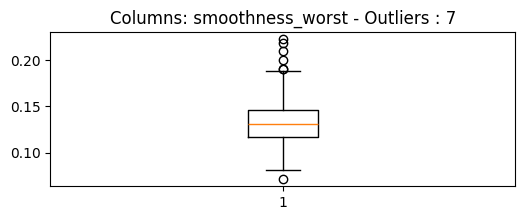

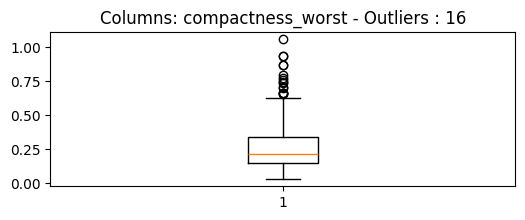

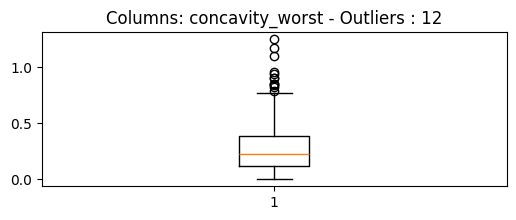

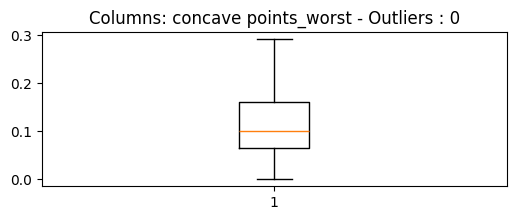

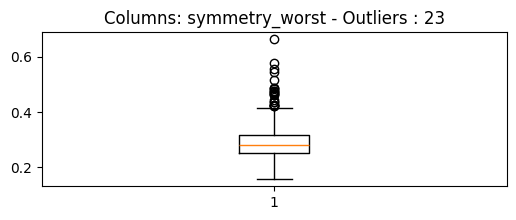

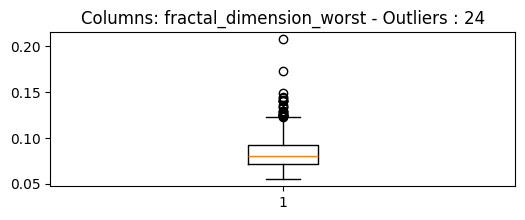

In [2]:
for col in numeric_cols:
  #df[col] will returns the series of data in that particular column
  q1= df[col].quantile(0.25)
  q3 =df[col].quantile(0.75)
  IQR =q3-q1

  lower = q1 - 1.5*IQR
  upper = q3 + 1.5*IQR

  outlier_mask = (df[col]<lower) | (df[col]>upper) #true when value is an outlier,will calculate if the value is less or greter
  number_outliers = outlier_mask.sum()

  plt.figure(figsize=(6,2)) #create a box with width 6 and height 2

  plt.boxplot(df[col].dropna())
  plt.title(f'Columns: {col} - Outliers : {number_outliers}')
  plt.show()
  #number_outliers = outlier_mask.sum()


In [3]:
X =  df.drop('diagnosis',axis=1) #feature matrix
y = df['diagnosis']
y = np.where(df['diagnosis'] == 'M',1,-1) #target labels
#by using this model we are analyzing the features and identifying the labels based on the features

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.20,random_state=42,stratify=y)
print(f"Total patients: {len(df)}")
print(f"Training set size: {len(X_train)/len(df)*100:.0f}%")
print(f"Test set size: {len(X_test)/len(df)*100:.0f}%")
print(f"Class split in training:  "
      f"{(y_train == -1).sum()/len(X_train)*100:.1f}% - Benign",
      f"{(y_train == 1).sum()/len(X_train)*100:.1f}% - Malignant",
      )
print(f"Class split in test:  "
      f"{(y_test == -1).sum()/len(X_test)*100:.1f}% - Benign",
      f"{(y_test == 1).sum()/len(X_test)*100:.1f}% - Malignant",
      )

Total patients: 569
Training set size: 80%
Test set size: 20%
Class split in training:  62.6% - Benign 37.4% - Malignant
Class split in test:  63.2% - Benign 36.8% - Malignant


In [5]:
#Remove outliers from training set
remove_outlier_mask = False
for col in numeric_cols:
  q1 = X_train[col].quantile(0.25)
  q3 = X_train[col].quantile(0.75)

  IQR = q3-q1

  lower = q1 - IQR*1.5
  upper = q3 + IQR*1.5

  is_outlier = (X_train[col]< lower) | (X_train[col] > upper)
  number_of_outliers = is_outlier.sum()
  print(number_outliers)

  if remove_outlier_mask and number_of_outliers > 0:
    median_val = X_train.loc[~is_outlier,col].median()  #.loc is an index identifier .loc[row_condtn,col]
    X_train.loc[is_outlier,col] = median_val

    #do the same in test data also
    is_test_outlier = (X_test[col] < lower) | (X_test[col] > upper)
    X_test[is_test_outlier,col] = median_val


24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24
24


In [6]:
#fix missing values

num_imputer = SimpleImputer(strategy = "median")
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

print(f"Empty Values:{X_train[numeric_cols].isna().sum()}")

Empty Values:Unnamed: 0                 0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [7]:
#scaling
#StandardScaler will generalise mean to 0 and stndard deviation to 1 across all features

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [8]:
#X = df.drop['diagnosis',axis = 1]

corr_matrix = X.corr()
plt.figure(figsize = (18,14))
print(corr_matrix)

sns.

                         Unnamed: 0  radius_mean  texture_mean  \
Unnamed: 0                 1.000000    -0.092895      0.066624   
radius_mean               -0.092895     1.000000      0.323782   
texture_mean               0.066624     0.323782      1.000000   
perimeter_mean            -0.099700     0.997855      0.329533   
area_mean                 -0.082966     0.987357      0.321086   
smoothness_mean           -0.169402     0.170581     -0.023389   
compactness_mean          -0.162487     0.506124      0.236702   
concavity_mean            -0.165151     0.676764      0.302418   
concave points_mean       -0.174718     0.822529      0.293464   
symmetry_mean             -0.192960     0.147741      0.071401   
fractal_dimension_mean    -0.071802    -0.311631     -0.076437   
radius_se                 -0.126542     0.679090      0.275869   
texture_se                 0.046544    -0.097317      0.386358   
perimeter_se              -0.115966     0.674172      0.281673   
area_se   

<Figure size 1800x1400 with 0 Axes>